In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
import time
from optic.models.tx import pamTransmitter
from optic.models.devices import photodiode, edfa, dac, adc, mzm, basicLaserModel
from optic.dsp.equalization import dfe, ffe
from optic.models.channels import linearFiberChannel, awgn
from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc, theoryBER
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate ,signalPower
from optic.utils import parameters, dBm2W, lin2dB
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

c:\Users\jezrael.filgueiras\anaconda3\Lib\site-packages\cupyx\jit\_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [2]:
from AnalyticalSNR import (
    superGauss,
    SNR_Folding,
    SNR_DFE,
    SNR_FFE,
    calc_S_th,
    calc_S_th_opticompy,
    calc_S_shot,
    calc_S_shot_opticompy,
    calc_S_RIN,
    calc_S_RIN_opticompy,
    calc_S_ADC,
    calc_S_ADC_opticompy,
    calc_S_N,
    calculate_oma_outer,
    get_spectral_snr,
    ber_from_snr_m_pam,
    calculate_ps2
)

In [3]:
def H_SMF_optical(f, DL_ps_nm, fc):
    """
    Função de transferência ÓTICA exata da fibra (Equação 12)
    DL_ps_nm: Dispersão acumulada D*L em ps/nm
    """
    c = 299792458
    # Conversão de ps/nm para s/m (Sistema Internacional): 1 ps/nm = 1e-12 s / 1e-9 m = 1e-3 s/m
    DL_SI = DL_ps_nm * 1e-3 
    return np.exp(1j * np.pi * c * DL_SI * (f/fc)**2)

def H_CD(f, D_L, fc):
    """
    Obtains the frequency response of chromatic disperion of a linear fiber

    param:
        f(np.array): frequency vector in Hz
        D(float): CD parameter of the fiber
        L(float): Length of the fiber channel
        fc(float): Central frequency of optical signal
    returns:
        H_cd(np.array): Frequency coefficients of linear fiber response
    """
    c = 299792458
    H_cd = np.cos(np.pi*c*D_L* (f/fc)**2)

    return H_cd


[1/11] Configurando Transmissor para ER = 2.00 dB
Potência Média do Sinal (P_TX): 0.00 dBm (1.000 mW)
ER obtido:    2.00 dB
  -> Processando D*L = 0.0 ps/nm


C:\Users\jezrael.filgueiras\AppData\Local\Temp\ipykernel_9616\2281708713.py:139: RuntimeWarning: invalid value encountered in log10
  snr_ffe_ana_dB = 10 * np.log10(SNR_FFE(SNR_folded, SIM_N, f_analytical, Rs))
C:\Users\jezrael.filgueiras\AppData\Local\Temp\ipykernel_9616\2281708713.py:140: RuntimeWarning: invalid value encountered in log10
  snr_dfe_ana_dB = 10 * np.log10(SNR_DFE(SNR_folded, SIM_N, f_analytical, Rs))
c:\users\jezrael.filgueiras\onedrive\documentos\opticommpy\optic\dsp\equalization.py:1218: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(prec)
c:\users\jezrael.filgueiras\onedrive\documentos\opticommpy\optic\dsp\equalization.py:1576: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(prec)


  -> Processando D*L = 18.4 ps/nm


C:\Users\jezrael.filgueiras\AppData\Local\Temp\ipykernel_9616\2281708713.py:139: RuntimeWarning: invalid value encountered in log10
  snr_ffe_ana_dB = 10 * np.log10(SNR_FFE(SNR_folded, SIM_N, f_analytical, Rs))
C:\Users\jezrael.filgueiras\AppData\Local\Temp\ipykernel_9616\2281708713.py:140: RuntimeWarning: invalid value encountered in log10
  snr_dfe_ana_dB = 10 * np.log10(SNR_DFE(SNR_folded, SIM_N, f_analytical, Rs))
c:\users\jezrael.filgueiras\onedrive\documentos\opticommpy\optic\dsp\equalization.py:1218: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(prec)
c:\users\jezrael.filgueiras\onedrive\documentos\opticommpy\optic\dsp\equalization.py:1576: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(prec)


  -> Processando D*L = 36.8 ps/nm
  -> Processando D*L = 55.3 ps/nm
  -> Processando D*L = 73.7 ps/nm
  -> Processando D*L = 92.1 ps/nm
  -> Processando D*L = 110.5 ps/nm
  -> Processando D*L = 128.9 ps/nm
  -> Processando D*L = 147.4 ps/nm
  -> Processando D*L = 165.8 ps/nm
  -> Processando D*L = 184.2 ps/nm
  -> Processando D*L = 202.6 ps/nm
  -> Processando D*L = 221.1 ps/nm
  -> Processando D*L = 239.5 ps/nm
  -> Processando D*L = 257.9 ps/nm
  -> Processando D*L = 276.3 ps/nm
  -> Processando D*L = 294.7 ps/nm
  -> Processando D*L = 313.2 ps/nm
  -> Processando D*L = 331.6 ps/nm
  -> Processando D*L = 350.0 ps/nm

[2/11] Configurando Transmissor para ER = 3.00 dB
Potência Média do Sinal (P_TX): 0.00 dBm (1.000 mW)
ER obtido:    3.00 dB
  -> Processando D*L = 0.0 ps/nm
  -> Processando D*L = 18.4 ps/nm
  -> Processando D*L = 36.8 ps/nm
  -> Processando D*L = 55.3 ps/nm
  -> Processando D*L = 73.7 ps/nm
  -> Processando D*L = 92.1 ps/nm
  -> Processando D*L = 110.5 ps/nm
  -> Proces

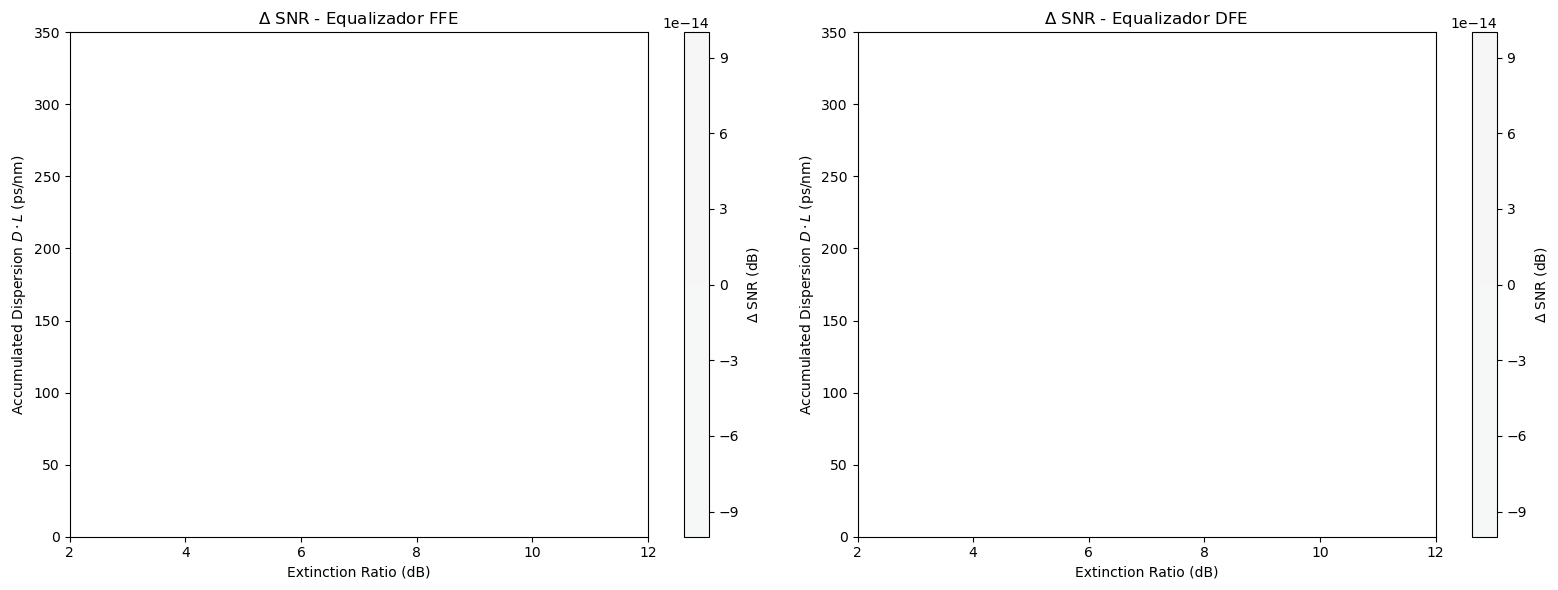

In [4]:
# =================================================================
# 2. CONFIGURAÇÕES GERAIS E DA VARREDURA
# =================================================================
R = 1.0
N0 = 2e-19
RIN = -140
M = 4
SIM_N = 10000        
SIM_fmax = 3e12
OMA_outer = 0.78

f_analytical = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
Rs = 25e9
SpS = 2
Fs = Rs * SpS
n_dac = 8
Res = 8
DAC_ADC = True
M = 4
P_avg_alvo = 1.0
c_speed = 299792458
lambda_c = 1310e-9 # 1310 nm
fc = c_speed / lambda_c

# Vetores de Varredura (Ajuste a resolução conforme a potência da sua máquina)
ER_range_dB = np.linspace(2, 12, 11)        # Eixo X: ER de 2 a 6 dB
DL_range_ps_nm = np.linspace(0, 350, 20)   # Eixo Y: D*L de 0 a 150 ps/nm

# Matrizes para armazenar o delta SNR (Simulação - Analítico)
delta_SNR_FFE = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))
delta_SNR_DFE = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))

# Frequências e parâmetros fixos do receptor
B_3dB = 0.4 * Rs
n_order = 1 
sim_Fs = n_dac * Fs

# Parâmetros Base (Gerados fora do loop para economizar processamento)
paramBits = parameters()
paramBits.nBits = 100000 # REDUZA PARA TESTAR (ex: 100000)
paramBits.mode = 'random'
paramBits.seed = 7
bits = bitSource(paramBits)

symb_Tx = modulateGray(bits, M, 'pam')
symb_Tx_up = upsample(symb_Tx, SpS)

paramPulse = parameters()
paramPulse.pulseType = 'rect'
paramPulse.SpS = SpS
pulse = pulseShape(paramPulse)
signal_Tx_base = firFilter(pulse, symb_Tx_up)

# =================================================================
# 3. LOOP PRINCIPAL (Varredura 2D)
# =================================================================
start_time = time.time()

for col, er_db in enumerate(ER_range_dB):
    print(f"\n[{col+1}/{len(ER_range_dB)}] Configurando Transmissor para ER = {er_db:.2f} dB")
    
    # 3.1. Reconfigurar o MZM para o novo ER
    ER_lin = 10**(er_db/10)
    x = (ER_lin - 1) / (ER_lin + 1)
    
    paramMZM = parameters()
    paramMZM.Vpi = 8
    paramMZM.Vb = -paramMZM.Vpi/2
    Vpp_calculado = (2 * paramMZM.Vpi / np.pi) * np.arcsin(x)
    
    paramDAC = parameters()
    paramDAC.inFs = Fs            
    paramDAC.outFs = sim_Fs       
    paramDAC.nBits = Res         
    paramDAC.ENOB = paramDAC.nBits          
    paramDAC.Vpp = Vpp_calculado          
    paramDAC.AIF = True  
    
    # Aplicação do DAC e/ou Normalização (Garante Vpp correto)
    if DAC_ADC:
        signal_Tx_DAC = dac(signal_Tx_base, paramDAC)
    else:
        paramDAC.outFs = Fs
        pico_sinal = np.max(np.abs(signal_Tx_base))
        signal_Tx_DAC = (signal_Tx_base / pico_sinal) * (Vpp_calculado / 2)
        
    # Calibração do Laser e Modulação
    E_unit = mzm(1.0 + 0j, signal_Tx_DAC, paramMZM)
    P_avg_unit = np.mean(np.abs(E_unit)**2) 
    Pi_dBm_calibrado = 10 * np.log10(P_avg_alvo / P_avg_unit)
    
    paramLaser = parameters()
    paramLaser.P = Pi_dBm_calibrado
    paramLaser.lw = 0
    paramLaser.RIN_var = 1e-14
    paramLaser.Fs = paramDAC.outFs
    paramLaser.Ns = len(signal_Tx_DAC)
    laserTx = basicLaserModel(paramLaser)
    
    signal_optTx = mzm(laserTx, signal_Tx_DAC, paramMZM)
    signal_optTx_fft = fft(signal_optTx)
    
    N_samples = len(signal_optTx)
    f_sim = fftfreq(N_samples, d=1/sim_Fs)
    
    # Obter OMA para o modelo analítico
    P_opt = np.abs(signal_optTx)**2
    idx_p3 = signal_Tx_DAC > 0.95 * np.max(signal_Tx_DAC)
    idx_p0 = signal_Tx_DAC < 0.95 * np.min(signal_Tx_DAC)
    P_avg_sim = np.mean(P_opt)
    P3_sim = np.mean(P_opt[idx_p3])
    P0_sim = np.mean(P_opt[idx_p0])
    OMA_sim = P3_sim - P0_sim
    ER_sim_dB = 10 * np.log10(P3_sim / P0_sim)

    print(f"Potência Média do Sinal (P_TX): {10*np.log10(P_avg_sim*1e3):.2f} dBm ({P_avg_sim*1e3:.3f} mW)")
    print(f"ER obtido:    {ER_sim_dB:.2f} dB")

    for row, dl in enumerate(DL_range_ps_nm):
        print(f"  -> Processando D*L = {dl:.1f} ps/nm")
        
        # --- PARTE A: MODELO ANALÍTICO ---
        # Filtro total = SuperGaussiano * Aproximação de CD
        H_ch_base = superGauss(f_analytical, n=n_order, B_3dB=B_3dB)
        H_cd_ana = H_CD(f_analytical, dl, fc)
        H_ch_total = H_ch_base * H_cd_ana
        H_ch_sq = np.abs(H_ch_total)**2
        
        # Recálculo dos ruídos analíticos com a nova H_ch_sq
        S_RIN_array = calc_S_RIN(P_avg_alvo**2, 1e-14, f_analytical) # Exemplo, ajuste com suas variáveis
        S_shot_array = calc_S_shot(P_avg_alvo*1e-3, 1, 1, 1, f_analytical) # R=1
        S_th_array = calc_S_th(N0, f_analytical) # Certifique-se de que N0 está definido no escopo
        
        S_N_total = calc_S_N(S_RIN_array, S_shot_array, S_th_array, 0, H_ch_sq, enable_S_ADC=False)
        Pulse_f = np.sinc(f_analytical / Rs)
        SNR_f = get_spectral_snr(f_analytical, OMA_outer, Rs, Pulse_f, H_ch_total, S_N_total)
        SNR_folded = SNR_Folding(SNR_f, f_analytical, mu=2, Rs=Rs)
        
        snr_ffe_ana_dB = 10 * np.log10(SNR_FFE(SNR_folded, SIM_N, f_analytical, Rs))
        snr_dfe_ana_dB = 10 * np.log10(SNR_DFE(SNR_folded, SIM_N, f_analytical, Rs))
        
        # --- PARTE B: SIMULAÇÃO (ÓTICA -> ELÉTRICA) ---
        # 1. Aplica o filtro ótico exato da fibra no campo complexo
        H_smf_opt = H_SMF_optical(f_sim, dl, fc)
        H_ch_sim = superGauss(f_sim, n=n_order, B_3dB=B_3dB)
        #H_cd_sim = H_CD(f_sim, dl, fc)

        signal_optRx_fiber = ifft(signal_optTx_fft * H_smf_opt)
        
        # 2. Fotodiodo (Onde ocorre a conversão intensidade-módulo quadrado natural)
        paramPD = parameters()
        paramPD.R = 1
        paramPD.Id = 1e-9                                    
        paramPD.RL = (4 * 1.38e-23 * (70 + 273.15)) / N0 
        paramPD.Fs = sim_Fs
        paramPD.ideal = False
        paramPD.shotNoise = True
        paramPD.thermalNoise = True
        paramPD.currentSaturation = False
        paramPD.bandwidthLimitation = False
        paramPD.seed = 7
        PD_signalR = photodiode(signal_optRx_fiber, paramPD)
        PD_signalRx = ifft(fft(PD_signalR)*H_ch_sim)
        
        # ADC e Filtro Casado
        paramAdc = parameters()
        paramAdc.inFs = sim_Fs
        paramAdc.outFs = Fs
        paramAdc.nBits = paramDAC.nBits
        paramAdc.ENOB = paramDAC.ENOB
        paramAdc.Vmax = np.max(np.abs(PD_signalRx))
        paramAdc.Vmin = -paramAdc.Vmax

        sigRx = adc(PD_signalRx, paramAdc) if DAC_ADC else PD_signalRx
        sigRx = firFilter(pulse, sigRx)
        
        # Equalizadores (FFE e DFE)
        # Atenção: Ajuste nTrain se necessário
        nTrain = 10000 
        paramDFE = parameters()
        paramDFE.nTapsFF = 200
        paramDFE.nTapsFB = 30
        paramDFE.SpS = 2
        paramDFE.mu = 2e-3
        paramDFE.nTrain = nTrain
        paramDFE.M = M
        paramDFE.trainingMode = "fulltime"
        outDFE, _, _, _ = dfe(sigRx, symb_Tx, paramDFE)
        outDFE = pnorm(outDFE)
        
        paramFFE = parameters()
        paramFFE.nTaps = 200
        paramFFE.mu = 2e-3
        paramFFE.nTrain = nTrain
        paramFFE.SpS = 2
        paramFFE.M = M
        paramFFE.trainingMode = "fulltime"
        outFFE, _, _ = ffe(sigRx, symb_Tx, paramFFE)
        outFFE = pnorm(outFFE)

        # Cálculo das SNRs Simuladas
        discard = nTrain
        _, _, snr_ffe_sim = fastBERcalc(outFFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        _, _, snr_dfe_sim = fastBERcalc(outDFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        
        # Salva as diferenças no array
        delta_SNR_FFE[row, col] = snr_ffe_sim[0] - snr_ffe_ana_dB
        delta_SNR_DFE[row, col] = snr_dfe_sim[0] - snr_dfe_ana_dB

print(f"\nVarredura Concluída em {(time.time() - start_time)/60:.2f} minutos.")

# =================================================================
# 4. PLOTAGEM DOS RESULTADOS (ESTILO FIGURA 5)
# =================================================================
X, Y = np.meshgrid(ER_range_dB, DL_range_ps_nm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot FFE
cp1 = ax1.contourf(X, Y, delta_SNR_FFE, levels=20, cmap='RdBu_r', vmin=-1.0, vmax=1.0)
fig.colorbar(cp1, ax=ax1, label='$\Delta$ SNR (dB)')
ax1.contour(X, Y, delta_SNR_FFE, levels=[-0.1, 0, 0.1], colors='black', linestyles='solid')
ax1.set_title('$\Delta$ SNR - Equalizador FFE')
ax1.set_xlabel('Extinction Ratio (dB)')
ax1.set_ylabel('Accumulated Dispersion $D \cdot L$ (ps/nm)')

# Plot DFE
cp2 = ax2.contourf(X, Y, delta_SNR_DFE, levels=20, cmap='RdBu_r', vmin=-1.0, vmax=1.0)
fig.colorbar(cp2, ax=ax2, label='$\Delta$ SNR (dB)')
ax2.contour(X, Y, delta_SNR_DFE, levels=[-0.1, 0, 0.1], colors='black', linestyles='dashed')
ax2.set_title('$\Delta$ SNR - Equalizador DFE')
ax2.set_xlabel('Extinction Ratio (dB)')
ax2.set_ylabel('Accumulated Dispersion $D \cdot L$ (ps/nm)')

plt.tight_layout()
plt.show()

Iniciando varredura analítica 2D. Aguarde...


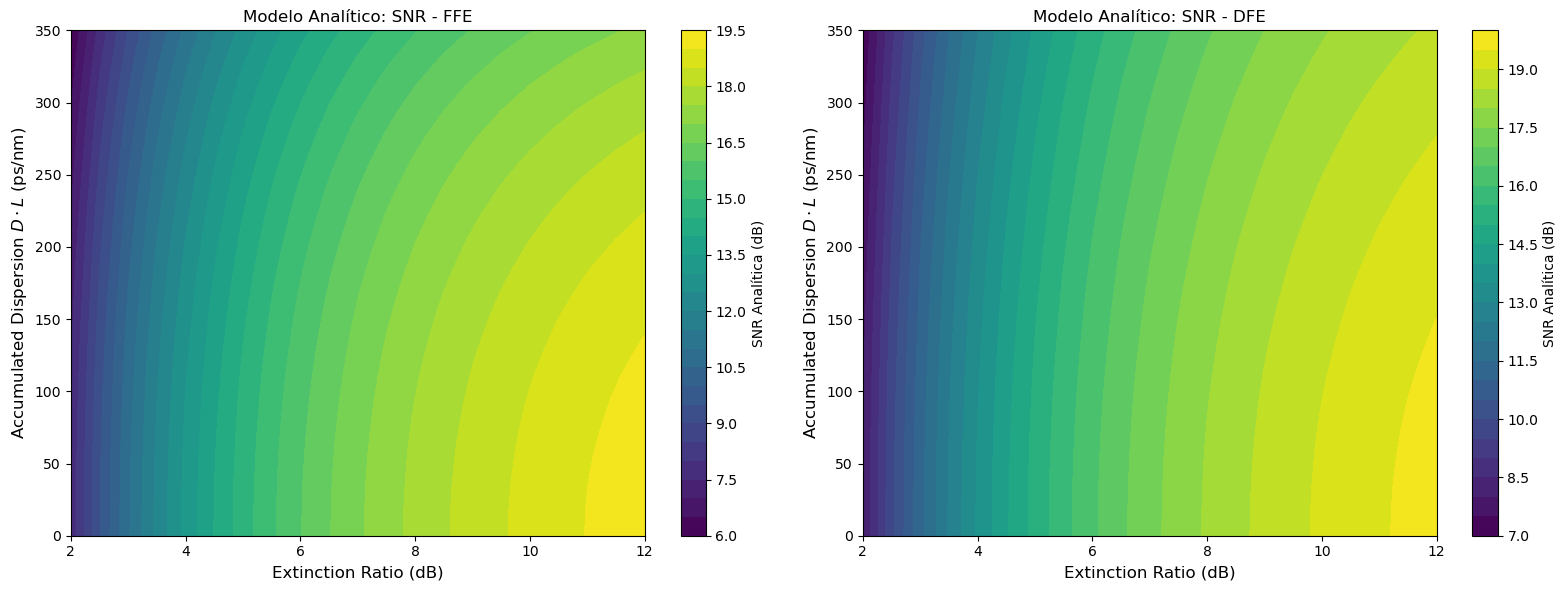

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 0. FUNÇÃO DA DISPERSÃO CROMÁTICA (Com conversão de S.I.)
# =================================================================
def H_CD(f, D_L_ps_nm, fc):
    c = 299792458
    # A conversão de ps/nm para s/m (1e-3) é vital para a fórmula não estourar
    DL_SI = D_L_ps_nm * 1e-3 
    return np.cos(np.pi * c * DL_SI * (f / fc)**2)

# =================================================================
# 1. PARÂMETROS GLOBAIS E CONSTANTES
# =================================================================
pTx_dBm = 0
pTx_W = 10**(pTx_dBm/10) * 1e-3
R = 1.0
N0 = 2e-19
RIN = -140
M = 4
Rs = 25e9
Tb = 1 / (Rs * 2)
TX_Ts = 1 / Rs

c_speed = 299792458
lambda_c = 1310e-9 
fc = c_speed / lambda_c

SIM_N = 10000        
SIM_fmax = 3e12      

# Eixos de frequência
f = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)

# Resposta do Pulso e Ruídos Fixos (Base)
Pulse = np.sinc(2 * Tb * f)
S_th = calc_S_th(N0, f)
S_shot = calc_S_shot(pTx_W, R, 1, 1, f) 

# =================================================================
# 2. PREPARAÇÃO DA VARREDURA 2D (Eixos do Gráfico)
# =================================================================
# Substituímos a varredura de banda por ER e D*L
ER_range_dB = np.linspace(2, 12, 21)        # Eixo X: 2 a 12 dB
DL_range_ps_nm = np.linspace(0, 350, 20)    # Eixo Y: 0 a 350 ps/nm

B_3dB = 0.4 * Rs  # Para esse gráfico, o artigo fixa a banda eletrônica!
n_order = 1       # Assumindo filtro supergaussiano de 1ª ordem

# Matrizes para guardar o eixo Z (Cores/SNR)
snr_ffe_matrix = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))
snr_dfe_matrix = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))

print("Iniciando varredura analítica 2D. Aguarde...")

# =================================================================
# 3. LOOP PRINCIPAL (ER e Dispersão)
# =================================================================
for col, er_db in enumerate(ER_range_dB):
    # Recalcula OMA e RIN para cada nível de ER
    OMA_outer = calculate_oma_outer(pTx_W, er_db)
    Ps2 = calculate_ps2(pTx_W, M, OMA_outer)
    S_RIN_global = calc_S_RIN(Ps2, RIN, f)
    
    for row, dl in enumerate(DL_range_ps_nm):
        
        # 1. Resposta do Canal (Elétrico + Dispersão)
        H_ch_base = superGauss(f, n=n_order, B_3dB=B_3dB)
        H_cd_ana = H_CD(f, dl, fc)
        
        # A MÁGICA ACONTECE AQUI: O canal total engloba a dispersão matemática
        H_ch_total = H_ch_base * H_cd_ana
        H_ch_sq = np.abs(H_ch_total)**2
        
        # 2. Ruído Total Global 
        S_N_total = calc_S_N(S_RIN_global, S_shot, S_th, 0, H_ch_sq, False)
        
        # 3. SNR Espectral (Global)
        S_N_f = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch_total, S_N_total)
        
        # Prevenindo Zeros Absolutos para o Log10 não quebrar
        S_N_f = np.maximum(np.nan_to_num(S_N_f, nan=1e-30), 1e-30)
        
        # 4. Folding e Integrais Globais
        SNR_folded = SNR_Folding(S_N_f, f, mu=2, Rs=Rs)
        safe_SNR = np.maximum(np.abs(SNR_folded), 1e-30) # Evita divide by zero
        SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(safe_SNR)) / 10)
        
        # Equalizadores
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        snr_dfe_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp + 1), x=f_int)) - 1
        
        # Armazena os resultados na matriz em dB
        snr_ffe_matrix[row, col] = 10 * np.log10(snr_ffe_lin)
        snr_dfe_matrix[row, col] = 10 * np.log10(snr_dfe_lin)

# =================================================================
# 4. PLOTAGEM DO MAPA DE CONTORNO
# =================================================================
X, Y = np.meshgrid(ER_range_dB, DL_range_ps_nm)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Mapa FFE
cp1 = ax1.contourf(X, Y, snr_ffe_matrix, levels=30, cmap='viridis')
fig.colorbar(cp1, ax=ax1, label='SNR Analítica (dB)')
ax1.set_title('Modelo Analítico: SNR - FFE')
ax1.set_xlabel('Extinction Ratio (dB)', fontsize=12)
ax1.set_ylabel('Accumulated Dispersion $D \cdot L$ (ps/nm)', fontsize=12)

# Mapa DFE
cp2 = ax2.contourf(X, Y, snr_dfe_matrix, levels=30, cmap='viridis')
fig.colorbar(cp2, ax=ax2, label='SNR Analítica (dB)')
ax2.set_title('Modelo Analítico: SNR - DFE')
ax2.set_xlabel('Extinction Ratio (dB)', fontsize=12)
ax2.set_ylabel('Accumulated Dispersion $D \cdot L$ (ps/nm)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
import time
import scipy.constants as const

# =================================================================
# 0. FUNÇÕES DA DISPERSÃO
# =================================================================
def H_CD(f, D_L_ps_nm, fc):
    c = 299792458
    DL_SI = D_L_ps_nm * 1e-3 
    return np.cos(np.pi * c * DL_SI * (f / fc)**2)

def H_SMF_optical(f, D_L_ps_nm, fc):
    c = 299792458
    DL_SI = D_L_ps_nm * 1e-3
    return np.exp(1j * np.pi * c * DL_SI * (f / fc)**2)

# =================================================================
# 1. PARÂMETROS GLOBAIS E EIXOS DA VARREDURA
# =================================================================
Rs = 25e9
P_avg_alvo = 1.0 # mW
M = 4
N0 = 2e-19
RIN = -140
c_speed = 299792458
lambda_c = 1310e-9 
fc = c_speed / lambda_c
kB = const.value("Boltzmann constant")
T_kelvin = 70 + 273.15

DAC_ADC = True # Configure conforme sua necessidade

SpS_TX = 2 if DAC_ADC else 16 
Fs = Rs * SpS_TX
n_dac = 8 if DAC_ADC else 1
Res = 8
sim_Fs = n_dac * Fs

B_3dB = 1.2 * Rs
n_order = 1 
SIM_N = 10000

# Eixos
ER_range_dB = np.linspace(2, 12, 11)        
DL_range_ps_nm = np.linspace(0, 350, 20)    

delta_SNR_FFE = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))
delta_SNR_DFE = np.zeros((len(DL_range_ps_nm), len(ER_range_dB)))

f_analytical = np.linspace(-3e12, 3e12, SIM_N + 1)
Pulse_f = np.sinc(f_analytical / Rs) 

print(f"Iniciando Varredura. Modo DAC_ADC = {DAC_ADC}. Aguarde...")
start_time = time.time()

# =================================================================
# 2. LOOP PRINCIPAL
# =================================================================
for col, er_db in enumerate(ER_range_dB):
    print(f"\n[{col+1}/{len(ER_range_dB)}] Processando ER = {er_db:.2f} dB")
    
    # --- TRANSMISSOR ---
    paramBits = parameters()
    paramBits.nBits = 100000  
    paramBits.mode = 'random'
    paramBits.seed = 7
    bits = bitSource(paramBits)

    symb_Tx = modulateGray(bits, M, 'pam')
    symb_Tx_up = upsample(symb_Tx, SpS_TX)

    paramPulse = parameters()
    paramPulse.pulseType = 'rect'
    paramPulse.SpS = SpS_TX
    pulse = pulseShape(paramPulse)
    
    signal_Tx_base = firFilter(pulse, symb_Tx_up)
    
    ER_lin = 10**(er_db/10)
    x = (ER_lin - 1) / (ER_lin + 1)
    
    paramMZM = parameters()
    paramMZM.Vpi = 8
    paramMZM.Vb = -paramMZM.Vpi/2
    Vpp_calculado = (2 * paramMZM.Vpi / np.pi) * np.arcsin(x)
    
    paramDAC = parameters()
    paramDAC.inFs = Fs            
    paramDAC.outFs = sim_Fs       
    paramDAC.nBits = Res         
    paramDAC.ENOB = paramDAC.nBits          
    paramDAC.Vpp = Vpp_calculado          
    paramDAC.AIF = True  
    
    if DAC_ADC:
        signal_Tx_DAC = dac(signal_Tx_base, paramDAC)
    else:
        paramDAC.outFs = Fs
        pico_sinal = np.max(np.abs(signal_Tx_base))
        signal_Tx_DAC = (signal_Tx_base / pico_sinal) * (Vpp_calculado / 2)
        
    E_unit = mzm(1.0 + 0j, signal_Tx_DAC, paramMZM)
    P_avg_unit = np.mean(np.abs(E_unit)**2) 
    Pi_dBm_calibrado = 10 * np.log10(P_avg_alvo / P_avg_unit)
    
    paramLaser = parameters()
    paramLaser.P = Pi_dBm_calibrado
    paramLaser.lw = 0
    paramLaser.RIN_var = 10**(RIN/10) 
    paramLaser.Fs = paramDAC.outFs
    paramLaser.Ns = len(signal_Tx_DAC)
    laserTx = basicLaserModel(paramLaser)
    
    signal_optTx = mzm(laserTx, signal_Tx_DAC, paramMZM)
    signal_optTx_fft = fft(signal_optTx)
    
    P_opt = np.abs(signal_optTx)**2
    idx_p3 = signal_Tx_DAC > 0.95 * np.max(signal_Tx_DAC)
    idx_p0 = signal_Tx_DAC < 0.95 * np.min(signal_Tx_DAC)
    OMA_sim_W = (np.mean(P_opt[idx_p3]) - np.mean(P_opt[idx_p0])) * 1e-3 
    P_avg_sim_W = np.mean(P_opt) * 1e-3 
    
    f_sim = fftfreq(len(signal_optTx), d=1/sim_Fs)
    
    # =================================================================
    # 3. LOOP INTERNO (Dispersão Acumulada D*L)
    # =================================================================
    for row, dl in enumerate(DL_range_ps_nm):
        
        # --- MODELO ANALÍTICO ---
        H_ch_base_ana = superGauss(f_analytical, n=n_order, B_3dB=B_3dB)
        H_cd_ana = H_CD(f_analytical, dl, fc)
        H_ch_total_ana = H_ch_base_ana * H_cd_ana
        H_ch_sq_ana = np.abs(H_ch_total_ana)**2
        
        S_RIN_array = calc_S_RIN((P_avg_sim_W)**2, 10**(RIN/10), f_analytical) 
        S_shot_array = calc_S_shot(P_avg_sim_W, 1.0, 1, 1, f_analytical) 
        S_th_array = calc_S_th(N0, f_analytical) 
        
        S_N_total = calc_S_N(S_RIN_array, S_shot_array, S_th_array, 0, H_ch_sq_ana, enable_S_ADC=False)
        SNR_f = get_spectral_snr(f_analytical, OMA_sim_W, Rs, Pulse_f, H_ch_total_ana, S_N_total)
        
        SNR_f = np.maximum(np.nan_to_num(SNR_f, nan=1e-30), 1e-30)
        SNR_folded = SNR_Folding(SNR_f, f_analytical, mu=2, Rs=Rs)
        SNR_folded = np.maximum(np.abs(SNR_folded), 1e-30)
        
        snr_ffe_ana_dB = 10 * np.log10(SNR_FFE(SNR_folded, SIM_N, f_analytical, Rs))
        snr_dfe_ana_dB = 10 * np.log10(SNR_DFE(SNR_folded, SIM_N, f_analytical, Rs))
        
        # --- SIMULAÇÃO ---
        # 1. Fibra Óptica (Atua no sinal óptico antes do fotodiodo)
        H_smf_opt = H_SMF_optical(f_sim, dl, fc)
        signal_optRx_fiber = ifft(signal_optTx_fft * H_smf_opt)
        
        # 2. Fotodiodo (Sem limitação de banda interna, apenas conversão O/E + Ruídos)
        paramPD = parameters()
        paramPD.R = 1.0
        paramPD.Id = 1e-9                                    
        paramPD.RL = (4 * kB * T_kelvin) / N0 
        paramPD.Fs = sim_Fs
        paramPD.ideal = False
        paramPD.shotNoise = True
        paramPD.thermalNoise = True
        paramPD.currentSaturation = False
        paramPD.bandwidthLimitation = False   # <--- Desligado para usarmos o Supergauss explicitamente
        paramPD.seed = 7
        PD_signalRx = photodiode(signal_optRx_fiber, paramPD)
        
        # 3. Filtro Passa-Baixas do Canal (Atua no domínio elétrico após o PD)
        H_ch_sim = superGauss(f_sim, n=n_order, B_3dB=B_3dB)
        PD_signalRx_filtered = np.real(ifft(fft(PD_signalRx) * H_ch_sim))
        
        # 4. ADC e Filtro Casado
        if DAC_ADC:
            paramAdc = parameters()
            paramAdc.inFs = sim_Fs
            paramAdc.outFs = Fs
            paramAdc.nBits = paramDAC.nBits
            paramAdc.ENOB = paramDAC.ENOB
            paramAdc.Vmax = np.max(np.abs(PD_signalRx_filtered))
            paramAdc.Vmin = -paramAdc.Vmax
            paramAdc.AAF = False 
            
            sigRx = adc(PD_signalRx_filtered, paramAdc)
            
            # Filtro casado - Comente a linha abaixo para testar o sistema sem ele
            sigRx = firFilter(pulse, sigRx)
        else:
            # Filtro casado - Comente a linha abaixo e substitua por sigRx_alta_res = PD_signalRx_filtered
            sigRx_alta_res = firFilter(pulse, PD_signalRx_filtered)
            
            fator_decimacao = SpS_TX // 2
            sigRx = sigRx_alta_res[::fator_decimacao]
        
        # Equalização DFE e FFE
        nTrain = int(len(symb_Tx) * 0.1) 
        
        paramDFE = parameters()
        paramDFE.nTapsFF = 30
        paramDFE.nTapsFB = 30
        paramDFE.SpS = 2
        paramDFE.mu = 2e-3
        paramDFE.nTrain = nTrain
        paramDFE.M = M
        paramDFE.trainingMode = "fulltime"
        outDFE, _, _, _ = dfe(sigRx, symb_Tx, paramDFE)
        outDFE = pnorm(outDFE)
        
        paramFFE = parameters()
        paramFFE.nTaps = 200
        paramFFE.mu = 2e-3
        paramFFE.nTrain = nTrain
        paramFFE.SpS = 2
        paramFFE.M = M
        paramFFE.trainingMode = "fulltime"
        outFFE, _, _ = ffe(sigRx, symb_Tx, paramFFE)
        outFFE = pnorm(outFFE)

        discard = nTrain
        _, _, snr_ffe_sim = fastBERcalc(outFFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        _, _, snr_dfe_sim = fastBERcalc(outDFE[discard:-discard//10], symb_Tx[discard:-discard//10], M, 'pam')
        
        delta_SNR_FFE[row, col] = np.abs(snr_ffe_sim[0] - snr_ffe_ana_dB)
        delta_SNR_DFE[row, col] = np.abs(snr_dfe_sim[0] - snr_dfe_ana_dB)

print(f"\nTempo Total: {(time.time() - start_time)/60:.2f} min")
print(f"Erro Máximo FFE: {np.max(delta_SNR_FFE):.2f} dB")
print(f"Erro Máximo DFE: {np.max(delta_SNR_DFE):.2f} dB")

# =================================================================
# 4. PLOTAGEM DO GRÁFICO (CONFORME O ARTIGO)
# =================================================================
X, Y = np.meshgrid(ER_range_dB, DL_range_ps_nm)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

niveis_desejados = np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])

# Plot FFE 
cs1 = ax1.contour(X, Y, delta_SNR_FFE, levels=niveis_desejados, colors='black', linewidths=1.5)
ax1.clabel(cs1, inline=True, fontsize=10, fmt='%.1f')
ax1.contourf(X, Y, delta_SNR_FFE, levels=niveis_desejados, cmap='Blues', alpha=0.2, extend='both')

ax1.set_title('$\Delta$SNR (dB) - FFE', fontsize=14)
ax1.set_xlabel('Extinction Ratio (dB)', fontsize=12)
ax1.set_ylabel('Accumulated Dispersion $D \cdot L$ (ps/nm)', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot DFE
cs2 = ax2.contour(X, Y, delta_SNR_DFE, levels=niveis_desejados, colors='black', linewidths=1.5, linestyles='dashed')
ax2.clabel(cs2, inline=True, fontsize=10, fmt='%.1f')
ax2.contourf(X, Y, delta_SNR_DFE, levels=niveis_desejados, cmap='Blues', alpha=0.2, extend='both')

ax2.set_title('$\Delta$SNR (dB) - DFE', fontsize=14)
ax2.set_xlabel('Extinction Ratio (dB)', fontsize=12)
ax2.set_ylabel('Accumulated Dispersion $D \cdot L$ (ps/nm)', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Iniciando Varredura. Modo DAC_ADC = True. Aguarde...

[1/11] Processando ER = 2.00 dB


C:\Users\jezrael.filgueiras\AppData\Local\Temp\ipykernel_9616\4123499872.py:150: RuntimeWarning: invalid value encountered in log10
  snr_ffe_ana_dB = 10 * np.log10(SNR_FFE(SNR_folded, SIM_N, f_analytical, Rs))
C:\Users\jezrael.filgueiras\AppData\Local\Temp\ipykernel_9616\4123499872.py:151: RuntimeWarning: invalid value encountered in log10
  snr_dfe_ana_dB = 10 * np.log10(SNR_DFE(SNR_folded, SIM_N, f_analytical, Rs))



[2/11] Processando ER = 3.00 dB

[3/11] Processando ER = 4.00 dB

[4/11] Processando ER = 5.00 dB

[5/11] Processando ER = 6.00 dB

[6/11] Processando ER = 7.00 dB

[7/11] Processando ER = 8.00 dB


Iniciando Varredura. Modo DAC_ADC = True. Aguarde...

[1/11] Processando ER = 2.00 dB


C:\Users\jezrael.filgueiras\AppData\Local\Temp\ipykernel_9616\1422950288.py:147: RuntimeWarning: invalid value encountered in log10
  snr_ffe_ana_dB = 10 * np.log10(SNR_FFE(SNR_folded, SIM_N, f_analytical, Rs))
C:\Users\jezrael.filgueiras\AppData\Local\Temp\ipykernel_9616\1422950288.py:148: RuntimeWarning: invalid value encountered in log10
  snr_dfe_ana_dB = 10 * np.log10(SNR_DFE(SNR_folded, SIM_N, f_analytical, Rs))



[2/11] Processando ER = 3.00 dB

[3/11] Processando ER = 4.00 dB

[4/11] Processando ER = 5.00 dB

[5/11] Processando ER = 6.00 dB

[6/11] Processando ER = 7.00 dB

[7/11] Processando ER = 8.00 dB

[8/11] Processando ER = 9.00 dB

[9/11] Processando ER = 10.00 dB

[10/11] Processando ER = 11.00 dB

[11/11] Processando ER = 12.00 dB

Tempo Total: 1.01 min
Erro Máximo FFE: nan dB
Erro Máximo DFE: nan dB


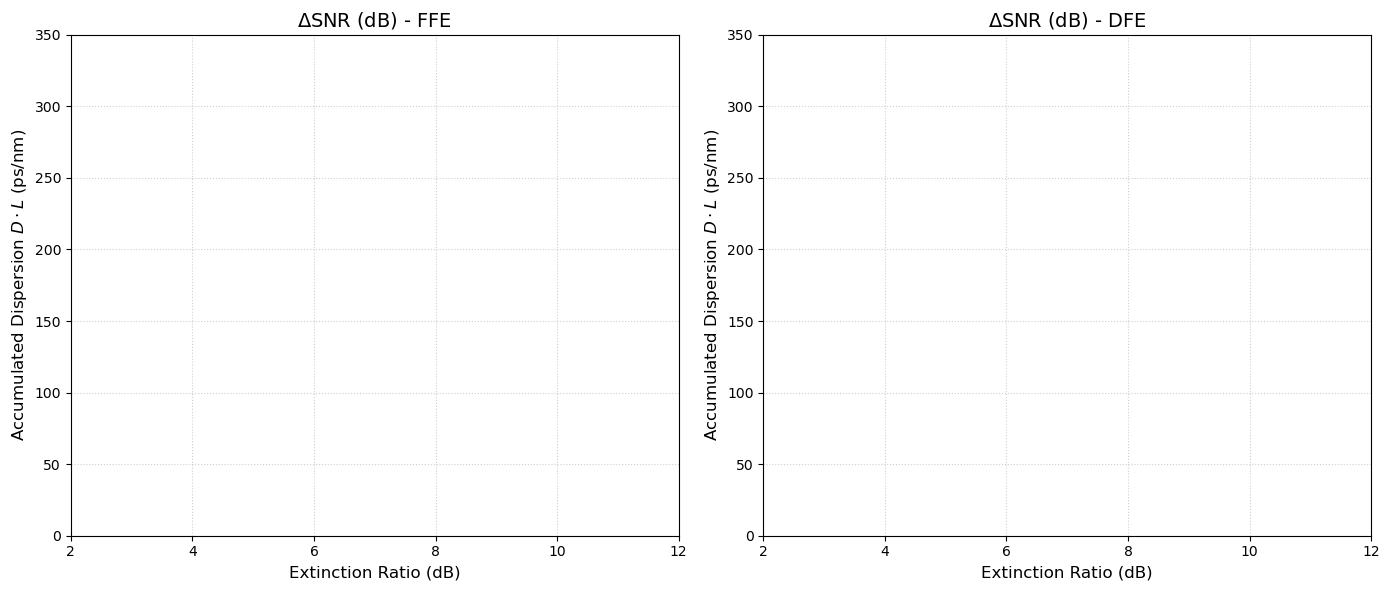